# De Regresion Simple a Multiple: Ecuacion Normal y Gradient Descent

**Pregunta:** Con una variable, la regresion lineal es solo seguir una formula. Pero con muchas variables, como funciona? Por que se necesita un algoritmo mas complejo?

---

## 1. Lo que ya sabemos — Regresion Simple

Con **una** variable, el modelo es:

$$\hat{y} = \beta_0 + \beta_1 x$$

Donde:
- $\hat{y}$: prediccion del modelo (ej: precio predicho de una casa)
- $\beta_0$: intercepto (valor de $\hat{y}$ cuando $x = 0$)
- $\beta_1$: pendiente (cuanto cambia $\hat{y}$ por cada unidad de cambio en $x$)
- $x$: la unica variable predictora (ej: area de la casa)

Los coeficientes se calculan con formulas directas:

$$\beta_1 = \frac{\sum_{i=1}^{n}(x_i - \bar{x})(y_i - \bar{y})}{\sum_{i=1}^{n}(x_i - \bar{x})^2}$$

Donde:
- $i$: indice que recorre cada observacion, de 1 a $n$ (ej: casa 1, casa 2, ..., casa $n$)
- $n$: numero total de observaciones (ej: 100 casas)
- $x_i$: valor de $x$ para la observacion $i$ (ej: area de la casa $i$)
- $\bar{x}$: media de todos los $x_i$ (ej: area promedio)
- $y_i$: valor real para la observacion $i$ (ej: precio real de la casa $i$)
- $\bar{y}$: media de todos los $y_i$

$$\beta_0 = \bar{y} - \beta_1 \bar{x}$$

**Ejemplo:** 3 casas con areas [50, 80, 120] y precios [150, 250, 350]:
- $\bar{x} = (50+80+120)/3 = 83.3$, $\bar{y} = (150+250+350)/3 = 250$
- $\beta_1 = \frac{(50-83.3)(150-250) + (80-83.3)(250-250) + (120-83.3)(350-250)}{(50-83.3)^2 + (80-83.3)^2 + (120-83.3)^2} = \frac{6999.9}{2866.7} = 2.44$

Esto funciona porque solo hay **dos incognitas**. Es como resolver un sistema de dos ecuaciones.

## 2. El salto a Regresion Multiple

Ahora el modelo es:

$$\hat{y} = \beta_0 + \beta_1 x_1 + \beta_2 x_2 + \ldots + \beta_p x_p$$

Donde:
- $p$: numero de variables predictoras (ej: $p=2$ si usamos area y habitaciones)
- $x_j$: la variable predictora numero $j$ (ej: $x_1$ = area, $x_2$ = habitaciones)
- $\beta_j$: el coeficiente que multiplica a $x_j$ (cuanto influye $x_j$ en la prediccion)
- $j$: indice que recorre las variables, de 0 a $p$ ($j=0$ es el intercepto)

Con **p variables**, necesitas **p+1 coeficientes** simultaneamente. Los $\beta_j$ **dependen unos de otros** — el efecto de $x_1$ sobre $y$ cambia segun que otras variables esten en el modelo.

Hay dos soluciones: la **Ecuacion Normal** (formula cerrada) y el **Gradient Descent** (iterativo).

## 3. Solucion 1: Ecuacion Normal (formula cerrada)

Existe una formula usando matrices:

$$\boldsymbol{\beta} = (\mathbf{X}^T \mathbf{X})^{-1} \mathbf{X}^T \mathbf{y}$$

Donde:
- $\mathbf{X}$: matriz de datos (n filas x (p+1) columnas, con columna de 1s para $\beta_0$)
- $\mathbf{y}$: vector de valores objetivo
- $\mathbf{X}^T$: transpuesta de X
- $(\mathbf{X}^T \mathbf{X})^{-1}$: inversa de $\mathbf{X}^T \mathbf{X}$

### Ejemplo numerico: predecir precio de casa con area y habitaciones

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

plt.style.use('seaborn-v0_8-whitegrid')
C_PRIMARY = '#3498db'
C_DANGER = '#e74c3c'
C_SUCCESS = '#2ecc71'
C_DARK = '#2c3e50'
C_ORANGE = '#f39c12'

# === Ejemplo: 3 casas, 2 variables ===
print("DATOS:")
print(f"{'Obs':>4} {'Area (x1)':>10} {'Habit (x2)':>10} {'Precio (y)':>10}")
print("-" * 40)
datos = [(50, 1, 150), (80, 2, 250), (120, 3, 350)]
for i, (a, h, p) in enumerate(datos, 1):
    print(f"{i:>4} {a:>10} {h:>10} {p:>10}")

# Paso 1: Construir matriz X (con columna de 1s)
X = np.array([[1, 50, 1],
              [1, 80, 2],
              [1, 120, 3]])
y = np.array([150, 250, 350])

print("\nPaso 1 — Matriz X (con columna de 1s para B0):")
print(X)
print(f"\nVector y: {y}")

DATOS:
 Obs  Area (x1) Habit (x2) Precio (y)
----------------------------------------
   1         50          1        150
   2         80          2        250
   3        120          3        350

Paso 1 — Matriz X (con columna de 1s para B0):
[[  1  50   1]
 [  1  80   2]
 [  1 120   3]]

Vector y: [150 250 350]


In [2]:
# Paso 2: X transpuesta
XT = X.T
print("Paso 2 — X transpuesta (X^T):")
print(XT)

# Paso 3: X^T @ X
XTX = XT @ X
print("\nPaso 3 — X^T X:")
print(XTX)

# Paso 4: X^T @ y
XTy = XT @ y
print("\nPaso 4 — X^T y:")
print(XTy)

# Paso 5: Invertir X^T X y multiplicar
XTX_inv = np.linalg.inv(XTX)
print("\nPaso 5 — (X^T X)^(-1):")
print(np.round(XTX_inv, 4))

# Resultado final
B = XTX_inv @ XTy
print(f"\nRESULTADO: B = (X^T X)^(-1) X^T y")
print(f"  B0 (intercepto)  = {B[0]:.4f}")
print(f"  B1 (area)        = {B[1]:.4f}")
print(f"  B2 (habitaciones)= {B[2]:.4f}")
print(f"\nModelo: precio = {B[0]:.2f} + {B[1]:.2f}*area + {B[2]:.2f}*habitaciones")

# Verificar con sklearn
from sklearn.linear_model import LinearRegression
lr = LinearRegression()
lr.fit(X[:, 1:], y)  # Sin la columna de 1s (sklearn la agrega)
print(f"\nVerificacion sklearn: B0={lr.intercept_:.4f}, B1={lr.coef_[0]:.4f}, B2={lr.coef_[1]:.4f}")

Paso 2 — X transpuesta (X^T):
[[  1   1   1]
 [ 50  80 120]
 [  1   2   3]]

Paso 3 — X^T X:
[[    3   250     6]
 [  250 23300   570]
 [    6   570    14]]

Paso 4 — X^T y:
[  750 69500  1700]

Paso 5 — (X^T X)^(-1):
[[ 1.3e+01 -8.0e-01  2.7e+01]
 [-8.0e-01  6.0e-02 -2.1e+00]
 [ 2.7e+01 -2.1e+00  7.4e+01]]

RESULTADO: B = (X^T X)^(-1) X^T y
  B0 (intercepto)  = 50.0000
  B1 (area)        = 0.0000
  B2 (habitaciones)= 100.0000

Modelo: precio = 50.00 + 0.00*area + 100.00*habitaciones

Verificacion sklearn: B0=50.0000, B1=-0.0000, B2=100.0000


### El problema de la Ecuacion Normal

Invertir una matriz de (p+1) x (p+1) tiene **complejidad O(p³)**:

| Features (p) | Operaciones | Viable? |
|---|---|---|
| 10 | 1,000 | Instantaneo |
| 100 | 1,000,000 | Rapido |
| 1,000 | 10⁹ | Lento |
| 10,000 | 10¹² | Impracticable |

---

## 4. Solucion 2: Gradient Descent (Descenso de Gradiente)

### La analogia

Estas en una **montana con niebla densa**. No ves el punto mas bajo. Solo puedes sentir la pendiente bajo tus pies. Gradient descent = **dar pasitos siempre cuesta abajo**. Eventualmente llegas al valle.

### La funcion de error (MSE)

$$MSE = \frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2$$

Donde:
- $n$: numero de muestras (ej: 100 casas)
- $i$: indice que recorre cada muestra, de 1 a $n$
- $y_i$: valor real de la muestra $i$
- $\hat{y}_i = \beta_0 + \beta_1 x_{i1} + \beta_2 x_{i2} + \ldots + \beta_p x_{ip}$: prediccion para la muestra $i$
- $x_{ij}$: valor de la feature $j$ para la muestra $i$ (ej: $x_{3,2}$ = habitaciones de la casa 3)

**Ejemplo:** 3 casas, $y = [150, 250, 350]$, $\hat{y} = [160, 240, 330]$:
- $MSE = \frac{(150-160)^2 + (250-240)^2 + (350-330)^2}{3} = \frac{100+100+400}{3} = 200$

### El gradiente: derivada parcial del MSE respecto a CADA beta

Para el coeficiente $\beta_j$ (el que multiplica a la feature $j$):

$$\frac{\partial MSE}{\partial \beta_j} = -\frac{2}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i) \cdot x_{ij}$$

Donde:
- $\frac{\partial MSE}{\partial \beta_j}$: "cuanto cambia el error si muevo SOLO $\beta_j$ un poquito"
- $j$: indice de la feature (ej: $j=1$ para area, $j=2$ para habitaciones)
- $(y_i - \hat{y}_i)$: error de la prediccion para la muestra $i$ (residuo)
- $x_{ij}$: valor de la feature $j$ para la muestra $i$
- La suma recorre TODAS las muestras ($i$ de 1 a $n$)

**Interpretacion:** El gradiente dice "el error total, ponderado por cuanto contribuye la feature $j$ a cada prediccion". Si $x_{ij}$ es grande y el error es grande, ese beta necesita moverse mucho.

**Ejemplo concreto:** Con 3 casas y $j=1$ (area):
- Errores: $y - \hat{y} = [-10, 10, 20]$
- Areas ($x_{i,1}$): $[50, 80, 120]$
- $\frac{\partial MSE}{\partial \beta_1} = -\frac{2}{3}[(-10 \cdot 50) + (10 \cdot 80) + (20 \cdot 120)] = -\frac{2}{3}[-500 + 800 + 2400] = -\frac{2}{3} \cdot 2700 = -1800$
- Gradiente negativo → $\beta_1$ debe SUBIR para reducir el error

### La regla de actualizacion

Para CADA coeficiente $\beta_j$ (de $j=0$ a $j=p$):

$$\beta_j := \beta_j - \alpha \cdot \frac{\partial MSE}{\partial \beta_j}$$

Donde:
- $\alpha$: learning rate (tamano del paso, ej: 0.01)
- El signo menos es porque bajamos "cuesta abajo" (opuesto al gradiente)

**Cada beta se actualiza con SU PROPIO gradiente.** Son $p+1$ actualizaciones independientes en cada epoch.

In [3]:
# === Gradient Descent desde cero (dataset mas grande para ver convergencia) ===
from sklearn.preprocessing import StandardScaler

np.random.seed(42)

# Dataset: 50 casas con 2 features (area, habitaciones) + ruido
n_samples = 50
X_raw = np.column_stack([
    np.random.uniform(40, 150, n_samples),   # Area (m2)
    np.random.randint(1, 5, n_samples)        # Habitaciones
])
# Precio real: 50 + 1.5*area + 30*habitaciones + ruido
y = 50 + 1.5 * X_raw[:, 0] + 30 * X_raw[:, 1] + np.random.normal(0, 15, n_samples)

print(f"Dataset: {n_samples} casas, 2 features (area, habitaciones)")
print(f"y (precio) rango: [{y.min():.0f}, {y.max():.0f}]")

# Escalar features (CRITICO para GD)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_raw)

# Agregar columna de 1s para beta_0
X_gd = np.column_stack([np.ones(n_samples), X_scaled])

# --- GRADIENT DESCENT ---
alpha = 0.05   # Learning rate (pequeno para ver la convergencia gradual)
epochs = 100
n = len(y)

# Inicializar betas en cero: beta_0=0, beta_1=0, beta_2=0
B = np.zeros(3)

# Guardar historial de CADA beta y el MSE
history = {'epoch': [], 'mse': [], 'B0': [], 'B1': [], 'B2': []}

for epoch in range(epochs):
    # 1. Predicciones: y_hat_i = B0 + B1*x_scaled_i1 + B2*x_scaled_i2
    y_hat = X_gd @ B  # Producto matricial: cada fila de X_gd por el vector B
    
    # 2. Errores: residuo_i = y_i - y_hat_i
    error = y - y_hat
    mse = np.mean(error**2)
    
    # 3. Gradientes: uno por cada beta_j
    # gradiente_j = -(2/n) * sum(error_i * x_ij) para todas las muestras i
    gradients = -(2/n) * (X_gd.T @ error)  # Vector de 3 gradientes [dMSE/dB0, dMSE/dB1, dMSE/dB2]
    
    # 4. Actualizar CADA beta con SU gradiente
    # B0 := B0 - alpha * dMSE/dB0
    # B1 := B1 - alpha * dMSE/dB1
    # B2 := B2 - alpha * dMSE/dB2
    B = B - alpha * gradients
    
    history['epoch'].append(epoch)
    history['mse'].append(mse)
    history['B0'].append(B[0])
    history['B1'].append(B[1])
    history['B2'].append(B[2])
    
    if epoch < 5 or epoch % 20 == 0 or epoch == epochs-1:
        print(f"  Epoch {epoch:>3}: MSE={mse:>10.2f}  B0={B[0]:>8.4f}  B1={B[1]:>8.4f}  B2={B[2]:>8.4f}")

# Solucion exacta (ecuacion normal)
B_exact = np.linalg.inv(X_gd.T @ X_gd) @ X_gd.T @ y
print(f"\nBetas GD (epoch {epochs}): B0={B[0]:.4f}, B1={B[1]:.4f}, B2={B[2]:.4f}")
print(f"Betas exactos (EN):      B0={B_exact[0]:.4f}, B1={B_exact[1]:.4f}, B2={B_exact[2]:.4f}")
print(f"Diferencia maxima: {np.max(np.abs(B - B_exact)):.6f}")

Dataset: 50 casas, 2 features (area, habitaciones)
y (precio) rango: [158, 376]
  Epoch   0: MSE=  72578.80  B0= 26.1980  B1=  5.0220  B2=  4.0041
  Epoch   1: MSE=  58758.98  B0= 49.7761  B1=  9.4987  B2=  7.5538
  Epoch   2: MSE=  47579.53  B0= 70.9965  B1= 13.4896  B2= 10.7005
  Epoch   3: MSE=  38535.73  B0= 90.0948  B1= 17.0476  B2= 13.4895
  Epoch   4: MSE=  31219.37  B0=107.2833  B1= 20.2199  B2= 15.9615
  Epoch  20: MSE=   1258.76  B0=233.3141  B1= 42.1873  B2= 32.3839
  Epoch  40: MSE=    224.64  B0=258.4945  B1= 45.9977  B2= 34.8399
  Epoch  60: MSE=    209.53  B0=261.5559  B1= 46.4017  B2= 35.0351
  Epoch  80: MSE=    209.30  B0=261.9281  B1= 46.4464  B2= 35.0476
  Epoch  99: MSE=    209.30  B0=261.9726  B1= 46.4515  B2= 35.0479

Betas GD (epoch 100): B0=261.9726, B1=46.4515, B2=35.0479
Betas exactos (EN):      B0=261.9796, B1=46.4524, B2=35.0477
Diferencia maxima: 0.006959


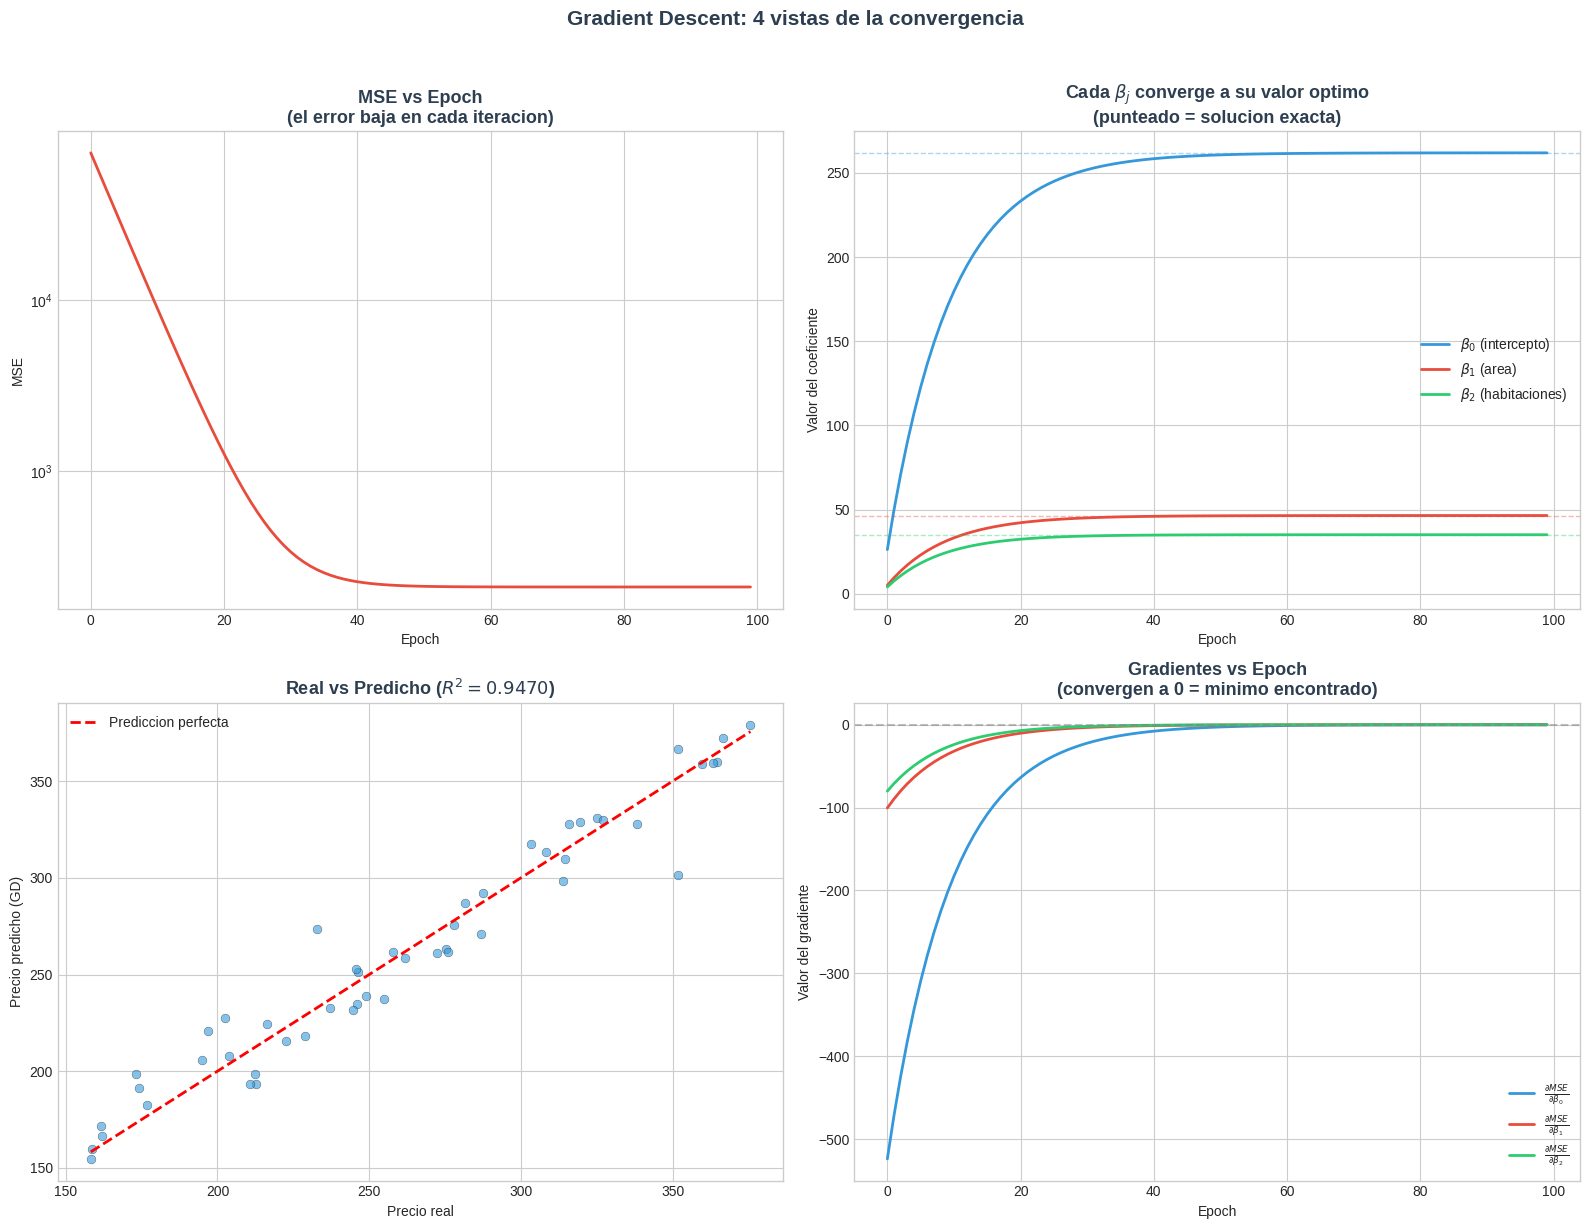

Arriba-izquierda: el error baja monotonamente (garantizado para MSE)
Arriba-derecha: cada beta se acerca a su valor optimo independientemente
Abajo-izquierda: las predicciones se alinean con la diagonal perfecta
Abajo-derecha: los gradientes se acercan a 0 (ya no hay pendiente = valle)


In [4]:
# === Visualizar convergencia de Gradient Descent ===
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. MSE vs Epoch (el error baja)
ax = axes[0, 0]
ax.plot(history['epoch'], history['mse'], color=C_DANGER, linewidth=2)
ax.set_title('MSE vs Epoch\n(el error baja en cada iteracion)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE')
ax.set_yscale('log')

# 2. Cada beta vs Epoch (los coeficientes convergen a su valor optimo)
ax = axes[0, 1]
ax.plot(history['epoch'], history['B0'], linewidth=2, label=r'$\beta_0$ (intercepto)', color=C_PRIMARY)
ax.plot(history['epoch'], history['B1'], linewidth=2, label=r'$\beta_1$ (area)', color=C_DANGER)
ax.plot(history['epoch'], history['B2'], linewidth=2, label=r'$\beta_2$ (habitaciones)', color=C_SUCCESS)
# Valores exactos como lineas punteadas
ax.axhline(y=B_exact[0], color=C_PRIMARY, linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(y=B_exact[1], color=C_DANGER, linestyle='--', alpha=0.4, linewidth=1)
ax.axhline(y=B_exact[2], color=C_SUCCESS, linestyle='--', alpha=0.4, linewidth=1)
ax.set_title('Cada $\\beta_j$ converge a su valor optimo\n(punteado = solucion exacta)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Epoch')
ax.set_ylabel('Valor del coeficiente')
ax.legend(fontsize=10)

# 3. Predicciones finales: real vs predicho
ax = axes[1, 0]
y_pred_gd = X_gd @ B
ax.scatter(y, y_pred_gd, color=C_PRIMARY, s=40, alpha=0.6, edgecolors='black', linewidth=0.3)
ax.plot([y.min(), y.max()], [y.min(), y.max()], 'r--', linewidth=2, label='Prediccion perfecta')
from sklearn.metrics import r2_score
r2 = r2_score(y, y_pred_gd)
ax.set_title(f'Real vs Predicho ($R^2 = {r2:.4f}$)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Precio real')
ax.set_ylabel('Precio predicho (GD)')
ax.legend()

# 4. Gradientes vs Epoch (se acercan a 0)
ax = axes[1, 1]
# Recalcular gradientes en cada epoch
grad_history = {'g0': [], 'g1': [], 'g2': []}
B_temp = np.zeros(3)
for epoch in range(epochs):
    y_hat = X_gd @ B_temp
    error = y - y_hat
    grads = -(2/n) * (X_gd.T @ error)
    grad_history['g0'].append(grads[0])
    grad_history['g1'].append(grads[1])
    grad_history['g2'].append(grads[2])
    B_temp = B_temp - alpha * grads

ax.plot(range(epochs), grad_history['g0'], linewidth=2, label=r'$\frac{\partial MSE}{\partial \beta_0}$', color=C_PRIMARY)
ax.plot(range(epochs), grad_history['g1'], linewidth=2, label=r'$\frac{\partial MSE}{\partial \beta_1}$', color=C_DANGER)
ax.plot(range(epochs), grad_history['g2'], linewidth=2, label=r'$\frac{\partial MSE}{\partial \beta_2}$', color=C_SUCCESS)
ax.axhline(0, color='gray', linestyle='--', alpha=0.5)
ax.set_title('Gradientes vs Epoch\n(convergen a 0 = minimo encontrado)', fontsize=13, fontweight='bold', color=C_DARK)
ax.set_xlabel('Epoch')
ax.set_ylabel('Valor del gradiente')
ax.legend(fontsize=9)

plt.suptitle('Gradient Descent: 4 vistas de la convergencia', fontsize=15, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print("Arriba-izquierda: el error baja monotonamente (garantizado para MSE)")
print("Arriba-derecha: cada beta se acerca a su valor optimo independientemente")
print("Abajo-izquierda: las predicciones se alinean con la diagonal perfecta")
print("Abajo-derecha: los gradientes se acercan a 0 (ya no hay pendiente = valle)")

## 5. El Learning Rate: el hiperparametro mas critico

- **Muy grande:** los betas saltan de un lado a otro y NUNCA convergen (divergen)
- **Muy pequeno:** converge pero tarda una eternidad
- **"Just right":** converge rapido y estable

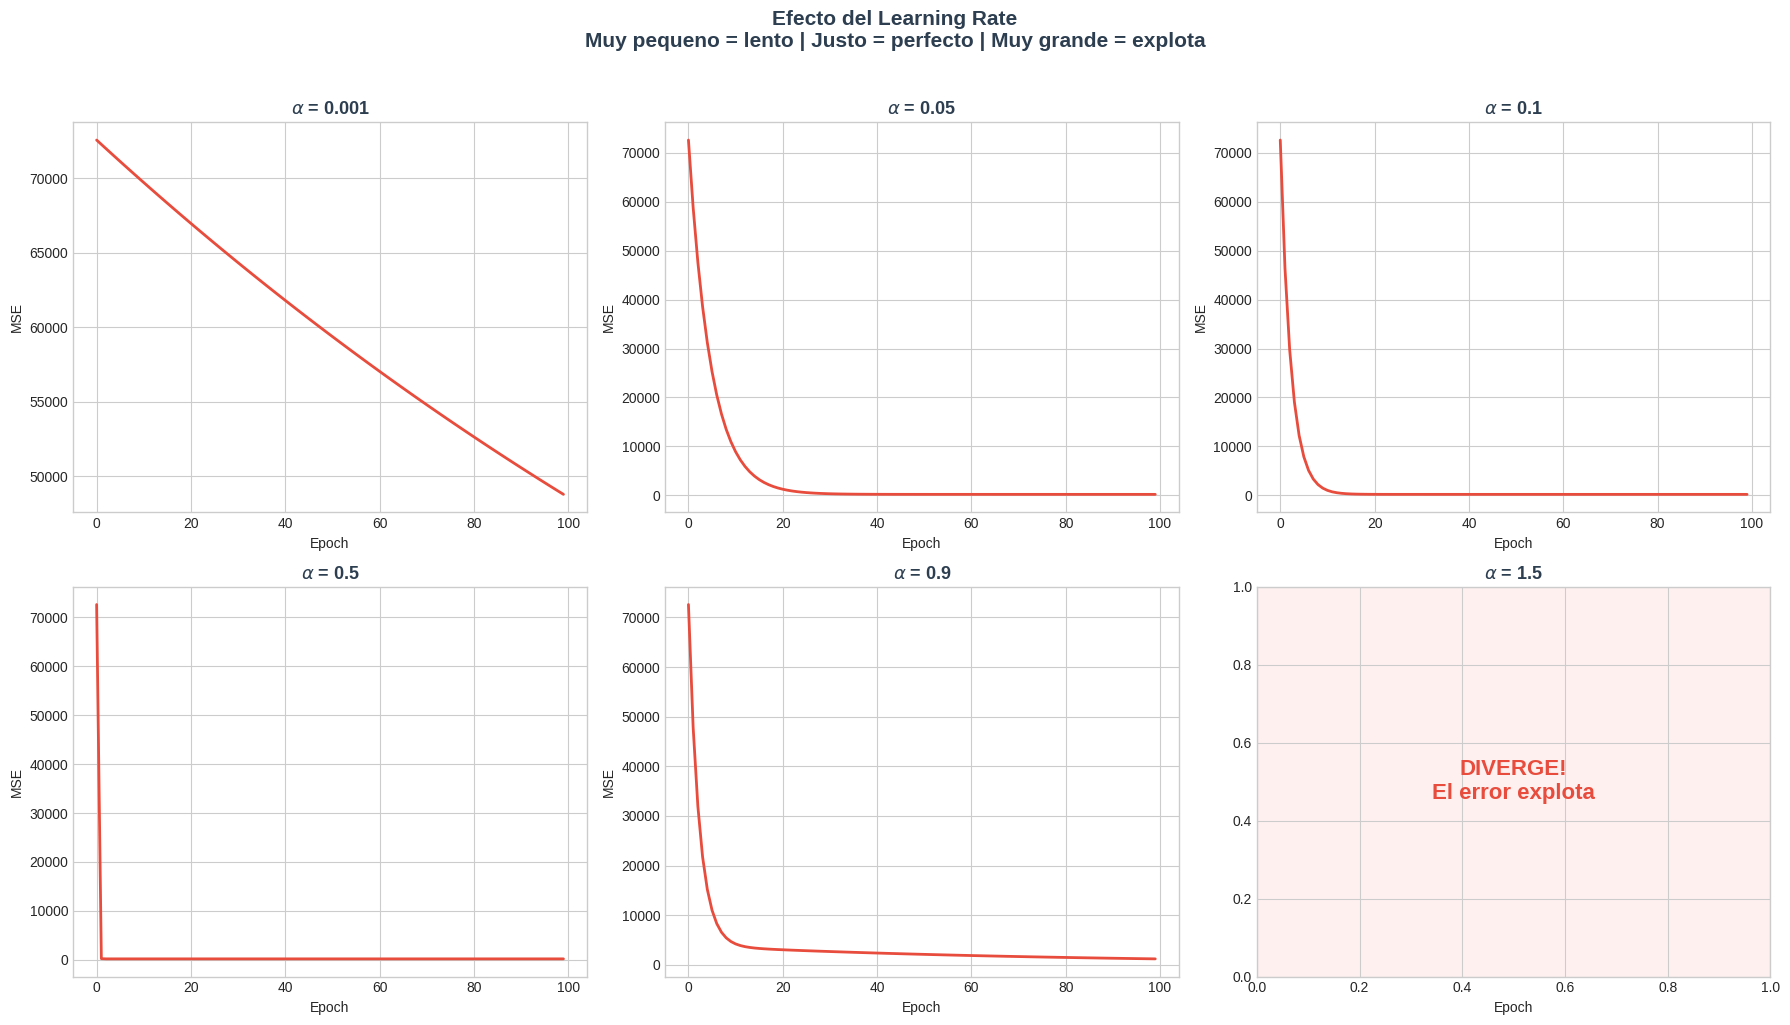

In [5]:
# === Efecto del learning rate ===
learning_rates = [0.001, 0.05, 0.1, 0.5, 0.9, 1.5]

fig, axes = plt.subplots(2, 3, figsize=(18, 10))
axes = axes.flatten()

for idx, lr in enumerate(learning_rates):
    ax = axes[idx]
    B_lr = np.zeros(3)
    mse_history = []
    diverged = False
    
    for epoch in range(100):
        y_hat = X_gd @ B_lr
        error = y - y_hat
        mse = np.mean(error**2)
        
        if mse > 1e10 or np.isnan(mse):
            diverged = True
            break
        
        mse_history.append(mse)
        gradients = -(2/n) * (X_gd.T @ error)
        B_lr = B_lr - lr * gradients
    
    if diverged:
        ax.text(0.5, 0.5, 'DIVERGE!\nEl error explota', transform=ax.transAxes,
                ha='center', va='center', fontsize=16, color=C_DANGER, fontweight='bold')
        ax.set_facecolor('#fff0f0')
    else:
        color = C_SUCCESS if mse_history[-1] < 1 else C_ORANGE if mse_history[-1] < 100 else C_DANGER
        ax.plot(mse_history, color=color, linewidth=2)
        ax.set_ylabel('MSE')
    
    ax.set_title(r'$\alpha$ = ' + f'{lr}', fontsize=13, fontweight='bold', color=C_DARK)
    ax.set_xlabel('Epoch')

plt.suptitle('Efecto del Learning Rate\nMuy pequeno = lento | Justo = perfecto | Muy grande = explota',
             fontsize=15, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

## 6. Variantes de Gradient Descent

| Variante | Datos por paso | Velocidad | Estabilidad |
|---|---|---|---|
| **Batch GD** | Todos los n datos | Lento | Estable, convergencia suave |
| **SGD** | 1 punto aleatorio | Muy rapido | Ruidoso, zigzaguea |
| **Mini-batch GD** | Subconjunto (32-256) | Rapido | Balance perfecto |

Mini-batch es el **estandar en deep learning**.

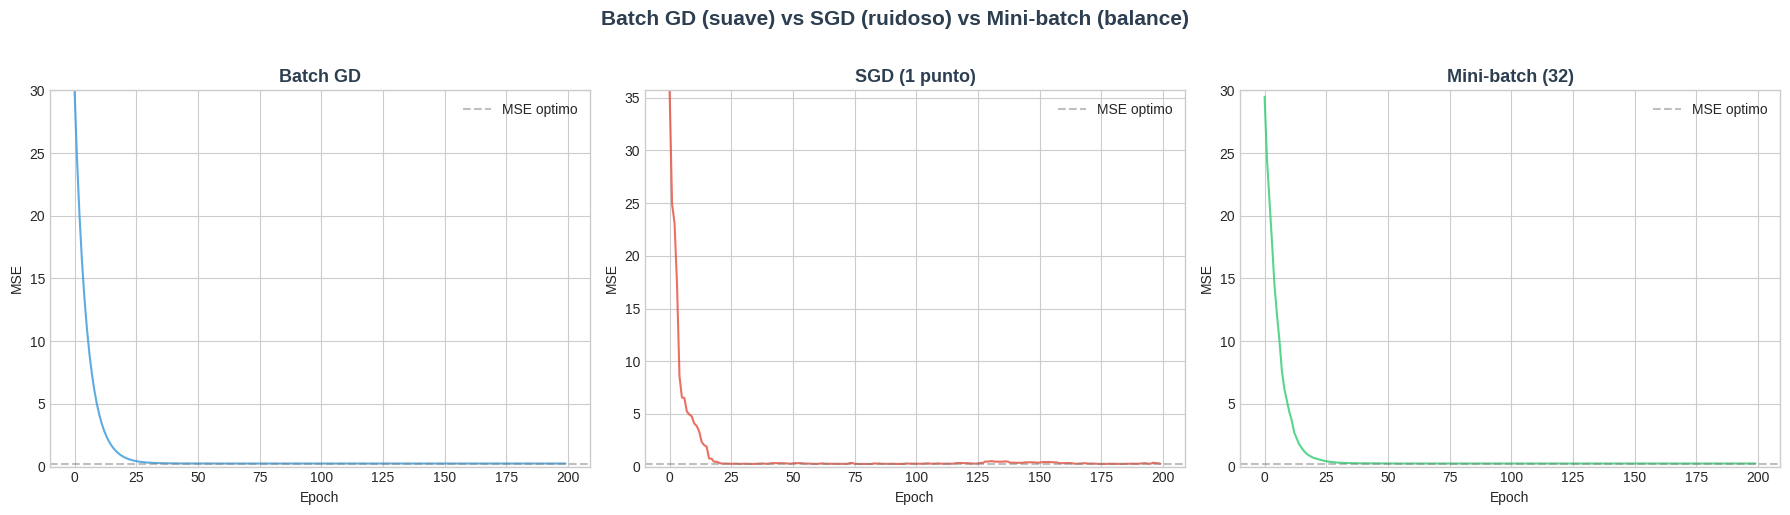

In [6]:
# === Comparar Batch GD vs SGD vs Mini-batch ===
# Dataset mas grande para ver la diferencia
np.random.seed(42)
n_samples = 200
X_large = np.random.randn(n_samples, 2)
true_B = np.array([5.0, 3.0, -2.0])
X_large_full = np.column_stack([np.ones(n_samples), X_large])
y_large = X_large_full @ true_B + np.random.randn(n_samples) * 0.5

B_exact_large = np.linalg.inv(X_large_full.T @ X_large_full) @ X_large_full.T @ y_large

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
methods = [
    ('Batch GD', None),
    ('SGD (1 punto)', 1),
    ('Mini-batch (32)', 32),
]

for ax, (name, batch_size) in zip(axes, methods):
    B_m = np.zeros(3)
    mse_hist = []
    np.random.seed(42)
    
    for epoch in range(200):
        if batch_size is None:
            # Batch: usa todos los datos
            X_batch = X_large_full
            y_batch = y_large
        else:
            # SGD o Mini-batch: subset aleatorio
            idx = np.random.choice(n_samples, size=batch_size, replace=False)
            X_batch = X_large_full[idx]
            y_batch = y_large[idx]
        
        y_hat = X_batch @ B_m
        error = y_batch - y_hat
        gradients = -(2/len(y_batch)) * (X_batch.T @ error)
        B_m = B_m - 0.05 * gradients
        
        # MSE sobre TODOS los datos (para comparar)
        full_error = y_large - X_large_full @ B_m
        mse_hist.append(np.mean(full_error**2))
    
    color = C_PRIMARY if batch_size is None else C_DANGER if batch_size == 1 else C_SUCCESS
    ax.plot(mse_hist, color=color, linewidth=1.5, alpha=0.8)
    ax.axhline(y=np.mean((y_large - X_large_full @ B_exact_large)**2), 
               color='gray', linestyle='--', alpha=0.5, label='MSE optimo')
    ax.set_title(name, fontsize=13, fontweight='bold', color=C_DARK)
    ax.set_xlabel('Epoch')
    ax.set_ylabel('MSE')
    ax.legend()
    ax.set_ylim(0, max(mse_hist[0], 30))

plt.suptitle('Batch GD (suave) vs SGD (ruidoso) vs Mini-batch (balance)',
             fontsize=15, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

## 7. Visualizar la "Montana" del Error

En 2D (un solo beta), la funcion de error es una parabola. Gradient descent baja por ella.
En 3D (dos betas), es un "cuenco". Podemos ver el camino que sigue gradient descent.

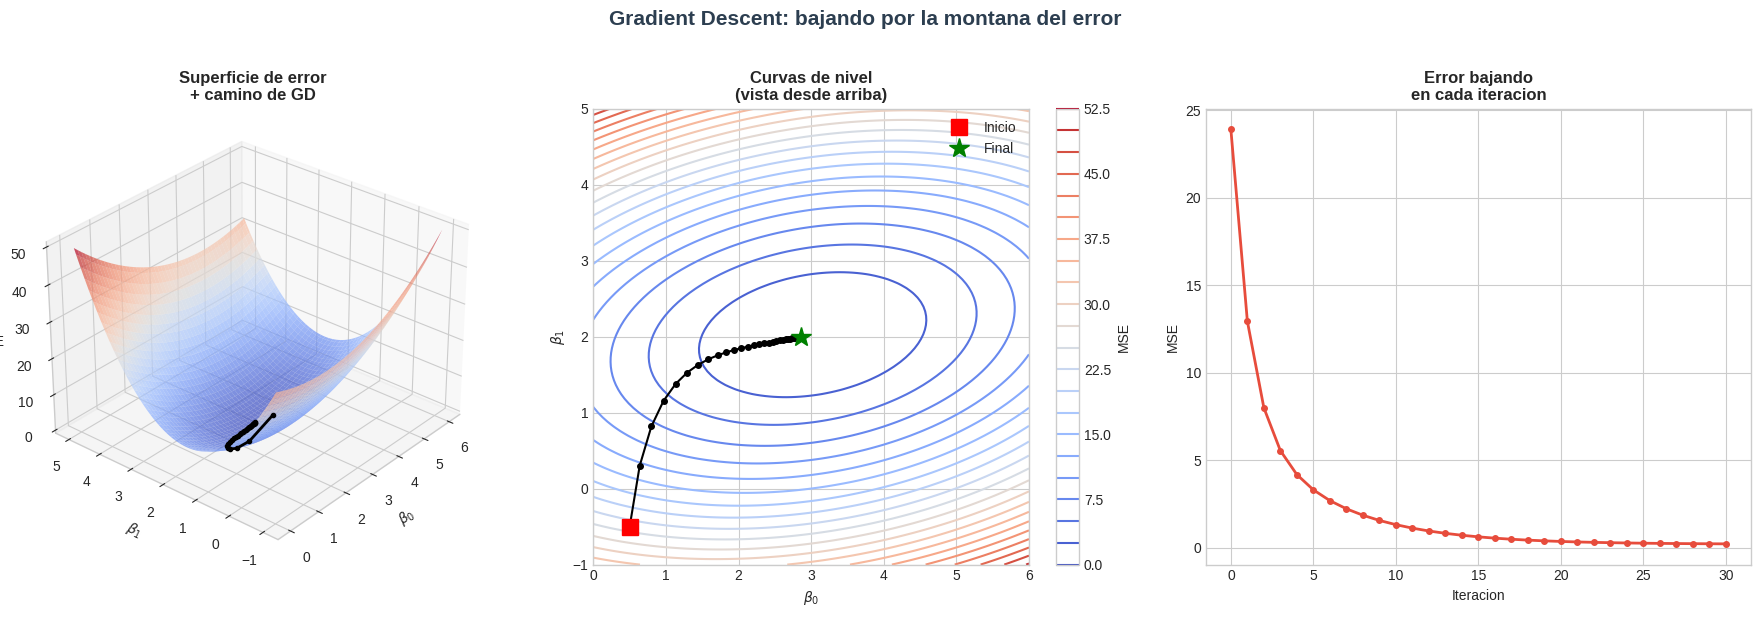

Observa como GD sigue las curvas de nivel 'cuesta abajo' hasta el minimo.
Con regresion lineal el minimo es UNICO (funcion convexa) — siempre lo encuentra.


In [7]:
# === Superficie de error 3D + camino de GD ===
from mpl_toolkits.mplot3d import Axes3D

# Datos simples
np.random.seed(42)
X_vis = np.random.randn(50, 1) * 2
y_vis = 3 + 2 * X_vis.ravel() + np.random.randn(50) * 0.5

# Crear malla de B0 y B1
b0_range = np.linspace(0, 6, 100)
b1_range = np.linspace(-1, 5, 100)
B0_grid, B1_grid = np.meshgrid(b0_range, b1_range)

# Calcular MSE para cada combinacion
MSE_grid = np.zeros_like(B0_grid)
for i in range(len(b0_range)):
    for j in range(len(b1_range)):
        y_hat = B0_grid[j, i] + B1_grid[j, i] * X_vis.ravel()
        MSE_grid[j, i] = np.mean((y_vis - y_hat)**2)

# Gradient descent trayectoria
B_path = [np.array([0.5, -0.5])]
alpha_vis = 0.05
X_vis_full = np.column_stack([np.ones(50), X_vis.ravel()])

for _ in range(30):
    B_curr = B_path[-1]
    y_hat = X_vis_full @ B_curr
    grad = -(2/50) * (X_vis_full.T @ (y_vis - y_hat))
    B_new = B_curr - alpha_vis * grad
    B_path.append(B_new)

B_path = np.array(B_path)
MSE_path = [np.mean((y_vis - X_vis_full @ b)**2) for b in B_path]

fig = plt.figure(figsize=(18, 6))

# 3D surface
ax1 = fig.add_subplot(131, projection='3d')
ax1.plot_surface(B0_grid, B1_grid, MSE_grid, cmap='coolwarm', alpha=0.7, edgecolor='none')
ax1.plot(B_path[:, 0], B_path[:, 1], MSE_path, 'ko-', markersize=3, linewidth=2, zorder=5)
ax1.set_xlabel(r'$\beta_0$')
ax1.set_ylabel(r'$\beta_1$')
ax1.set_zlabel('MSE')
ax1.set_title('Superficie de error\n+ camino de GD', fontsize=12, fontweight='bold')
ax1.view_init(elev=30, azim=220)

# Contour plot (vista desde arriba)
ax2 = fig.add_subplot(132)
contour = ax2.contour(B0_grid, B1_grid, MSE_grid, levels=20, cmap='coolwarm')
ax2.plot(B_path[:, 0], B_path[:, 1], 'ko-', markersize=4, linewidth=1.5)
ax2.plot(B_path[0, 0], B_path[0, 1], 'rs', markersize=12, label='Inicio')
ax2.plot(B_path[-1, 0], B_path[-1, 1], 'g*', markersize=15, label='Final')
ax2.set_xlabel(r'$\beta_0$')
ax2.set_ylabel(r'$\beta_1$')
ax2.set_title('Curvas de nivel\n(vista desde arriba)', fontsize=12, fontweight='bold')
ax2.legend()
plt.colorbar(contour, ax=ax2, label='MSE')

# MSE por iteracion
ax3 = fig.add_subplot(133)
ax3.plot(MSE_path, 'o-', color=C_DANGER, linewidth=2, markersize=4)
ax3.set_xlabel('Iteracion')
ax3.set_ylabel('MSE')
ax3.set_title('Error bajando\nen cada iteracion', fontsize=12, fontweight='bold')

plt.suptitle('Gradient Descent: bajando por la montana del error',
             fontsize=15, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print("Observa como GD sigue las curvas de nivel 'cuesta abajo' hasta el minimo.")
print("Con regresion lineal el minimo es UNICO (funcion convexa) — siempre lo encuentra.")

## 8. Por que escalar es CRITICO para Gradient Descent

Sin escalar, la superficie de error es un "valle alargado" (las escalas de las features son muy distintas). GD zigzaguea. Con features escaladas, la superficie es un cuenco circular y GD va directo al minimo.

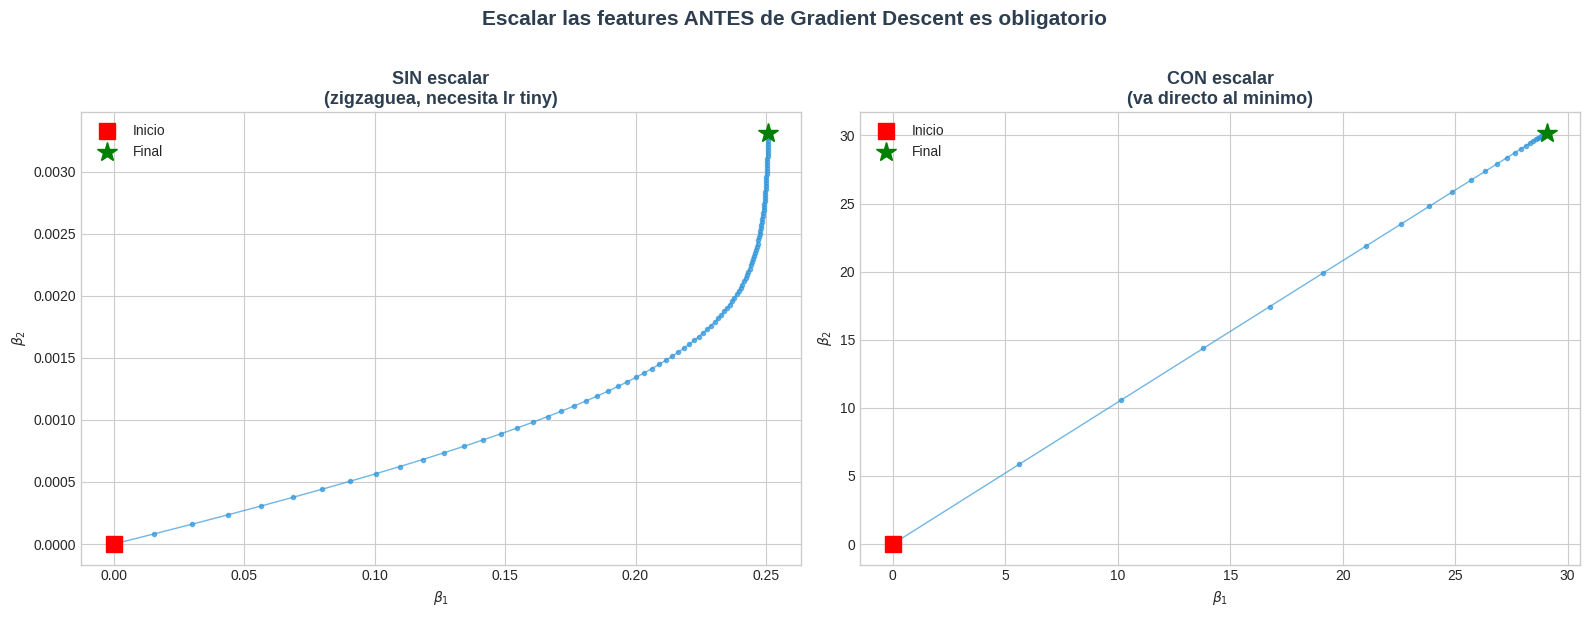

Sin escalar: el learning rate tiene que ser 0.0000001 (por la feature de area ~1000)
Con escalar: el learning rate puede ser 0.1 y converge directo.
Por eso StandardScaler o MinMaxScaler ANTES de GD es obligatorio.


In [8]:
# === Sin escalar vs escalado ===
np.random.seed(42)
# Feature 1: rango [0, 1000] (area)
# Feature 2: rango [0, 5] (habitaciones)
X_unscaled = np.column_stack([
    np.random.uniform(0, 1000, 100),
    np.random.uniform(0, 5, 100)
])
y_sc = 50 + 0.1 * X_unscaled[:, 0] + 20 * X_unscaled[:, 1] + np.random.randn(100) * 5

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

for ax, do_scale, title in [(axes[0], False, 'SIN escalar\n(zigzaguea, necesita lr tiny)'),
                              (axes[1], True, 'CON escalar\n(va directo al minimo)')]:
    if do_scale:
        sc = StandardScaler()
        X_use = sc.fit_transform(X_unscaled)
        lr_use = 0.1
    else:
        X_use = X_unscaled.copy()
        lr_use = 0.0000001  # Tiene que ser MINUSCULO
    
    X_full = np.column_stack([np.ones(100), X_use])
    B_sc = np.zeros(3)
    path_b1 = [B_sc[1]]
    path_b2 = [B_sc[2]]
    
    for _ in range(100):
        y_hat = X_full @ B_sc
        grad = -(2/100) * (X_full.T @ (y_sc - y_hat))
        B_sc = B_sc - lr_use * grad
        path_b1.append(B_sc[1])
        path_b2.append(B_sc[2])
    
    ax.plot(path_b1, path_b2, 'o-', markersize=3, linewidth=1, color=C_PRIMARY, alpha=0.7)
    ax.plot(path_b1[0], path_b2[0], 'rs', markersize=12, label='Inicio')
    ax.plot(path_b1[-1], path_b2[-1], 'g*', markersize=15, label='Final')
    ax.set_xlabel(r'$\beta_1$')
    ax.set_ylabel(r'$\beta_2$')
    ax.set_title(title, fontsize=13, fontweight='bold', color=C_DARK)
    ax.legend()

plt.suptitle('Escalar las features ANTES de Gradient Descent es obligatorio',
             fontsize=15, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print("Sin escalar: el learning rate tiene que ser 0.0000001 (por la feature de area ~1000)")
print("Con escalar: el learning rate puede ser 0.1 y converge directo.")
print("Por eso StandardScaler o MinMaxScaler ANTES de GD es obligatorio.")

## 9. Cuando usar cada metodo

| Metodo | Cuando | Ejemplo |
|---|---|---|
| **Ecuacion Normal** | <1000 features, dataset mediano | `LinearRegression().fit(X, y)` |
| **Gradient Descent** | Muchas features, datos enormes | `SGDRegressor()`, redes neuronales |

### La conexion mas importante

Gradient Descent **no es solo para regresion lineal**. Es el algoritmo fundamental de **todo deep learning**:
- Una red neuronal tiene millones de parametros
- No existe formula cerrada para encontrarlos
- La unica opcion es gradient descent (con variantes como Adam, SGD con momentum)

La regresion lineal con gradient descent es el **caso mas simple** para entender la mecanica que despues se aplica a LSTM, transformers, GPT, etc.

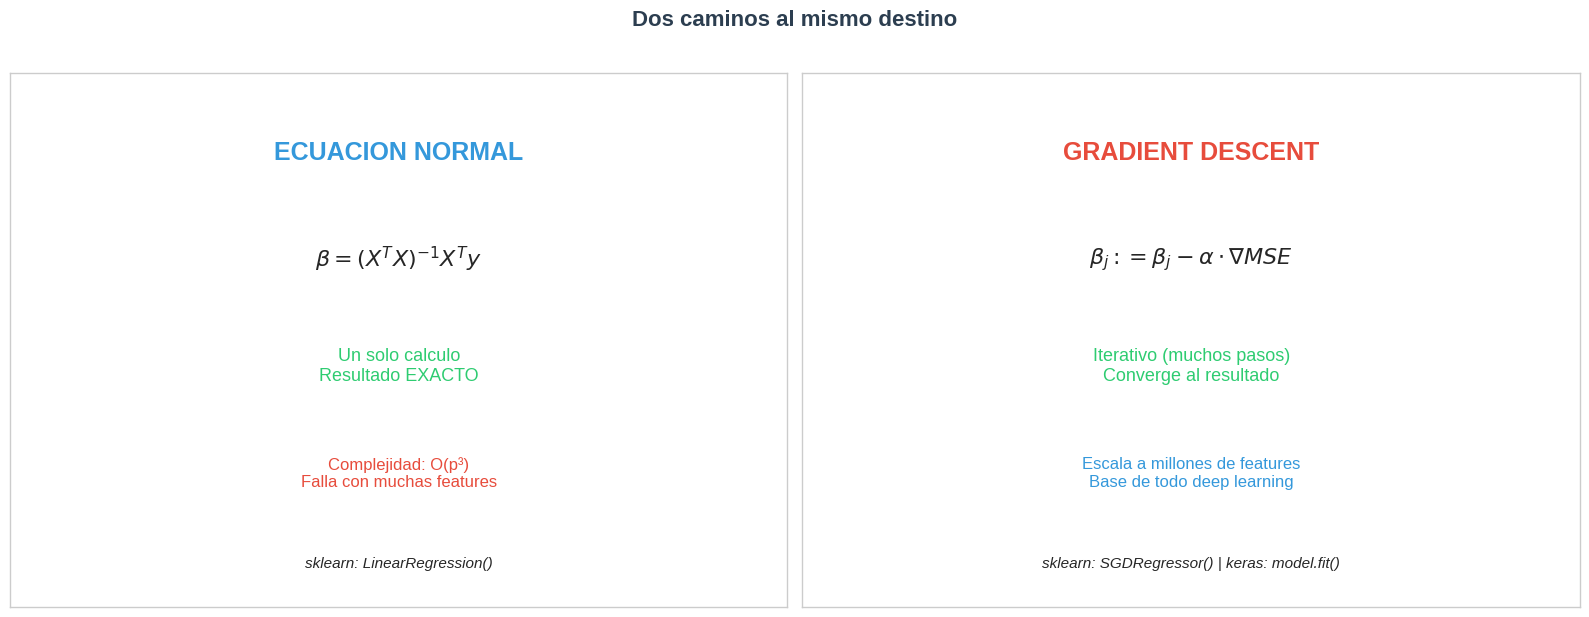

Ambos metodos dan el MISMO resultado para regresion lineal.
La diferencia es computacional: uno es directo, el otro iterativo.
Gradient descent es el unico viable para deep learning.


In [9]:
# === Resumen visual: Ecuacion Normal vs Gradient Descent ===
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Ecuacion Normal: solucion directa
ax = axes[0]
ax.text(0.5, 0.85, 'ECUACION NORMAL', ha='center', va='center', fontsize=18, fontweight='bold', color=C_PRIMARY)
ax.text(0.5, 0.65, r'$\beta = (X^T X)^{-1} X^T y$', ha='center', va='center', fontsize=16)
ax.text(0.5, 0.45, 'Un solo calculo\nResultado EXACTO', ha='center', va='center', fontsize=13, color=C_SUCCESS)
ax.text(0.5, 0.25, 'Complejidad: O(p³)\nFalla con muchas features', ha='center', va='center', fontsize=12, color=C_DANGER)
ax.text(0.5, 0.08, 'sklearn: LinearRegression()', ha='center', va='center', fontsize=11, style='italic')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])

# Gradient Descent: iterativo
ax = axes[1]
ax.text(0.5, 0.85, 'GRADIENT DESCENT', ha='center', va='center', fontsize=18, fontweight='bold', color=C_DANGER)
ax.text(0.5, 0.65, r'$\beta_j := \beta_j - \alpha \cdot \nabla MSE$', ha='center', va='center', fontsize=16)
ax.text(0.5, 0.45, 'Iterativo (muchos pasos)\nConverge al resultado', ha='center', va='center', fontsize=13, color=C_SUCCESS)
ax.text(0.5, 0.25, 'Escala a millones de features\nBase de todo deep learning', ha='center', va='center', fontsize=12, color=C_PRIMARY)
ax.text(0.5, 0.08, 'sklearn: SGDRegressor() | keras: model.fit()', ha='center', va='center', fontsize=11, style='italic')
ax.set_xlim(0, 1)
ax.set_ylim(0, 1)
ax.set_xticks([])
ax.set_yticks([])

plt.suptitle('Dos caminos al mismo destino', fontsize=16, fontweight='bold', color=C_DARK, y=1.02)
plt.tight_layout()
plt.show()

print("Ambos metodos dan el MISMO resultado para regresion lineal.")
print("La diferencia es computacional: uno es directo, el otro iterativo.")
print("Gradient descent es el unico viable para deep learning.")